## IX. Model Inference

### 9.1. Load Model & Setup

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [13]:
# Load model format .h5 yang sudah disimpan sebelumnya
model_path = 'P2G7_risyadhana_model.h5'
model = load_model(model_path)

# Daftar label sesuai urutan alphabet (pastikan urutan ini sama dengan saat training)
# Biasanya: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_names = ['Buildings', 'Forest', 'Glacier', 'Mountain', 'Sea', 'Street']

print("Model loaded successfully!")

Model loaded successfully!


### 9.2. Inference Function with Safety Logic

Fungsi ini tidak hanya menebak kelas, tapi juga mengecek tingkat kepercayaan model.

In [14]:
def predict_drone_vision(img_path, threshold=0.69):
    """
    Fungsi untuk memproses gambar dan memberikan prediksi medan
    lengkap dengan tingkat kepercayaan (Confidence Score).
    """
    # Load gambar asli
    img_display = image.load_img(img_path)

    # Preprocessing (Resize ke 150x150 & Normalisasi 1/255 sesuai Feature Engineering)
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Ubah jadi batch (1, 150, 150, 3)
    img_array /= 255.0  # Normalisasi sangat krusial!

    # Proses Prediksi
    predictions = model.predict(img_array, verbose=0)
    score = np.max(predictions) # Ambil probabilitas tertinggi
    class_idx = np.argmax(predictions) # Ambil indeks kelasnya

    # Visualisasi Hasil
    plt.figure(figsize=(6, 5))
    plt.imshow(img_display)
    plt.axis('off')

    # LOGIKA SAFETY: Confidence Thresholding
    # Jika score di bawah threshold, anggap sebagai objek tidak dikenal (Out-of-Distribution)
    if score < threshold:
        title_text = f"WARNING: UNKNOWN OBJECT DETECTED\nConfidence: {score:.2f}"
        title_color = 'red'
    else:
        title_text = f"RESULT: {class_names[class_idx].upper()}\nConfidence: {score:.2f}"
        title_color = 'green'

    plt.title(title_text, color=title_color, fontsize=12, fontweight='bold')
    plt.show()

    # Return hasil untuk keperluan logging jika dibutuhkan
    return class_names[class_idx] if score >= threshold else "Unknown"

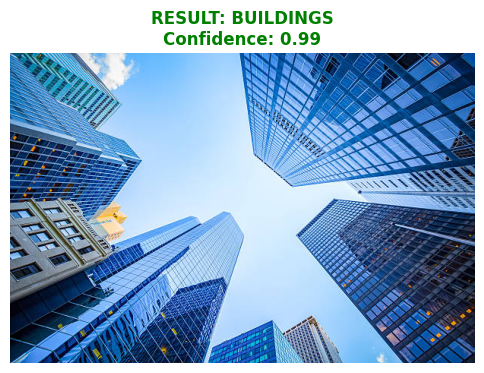

'Buildings'

In [15]:
predict_drone_vision('img2.jpg')

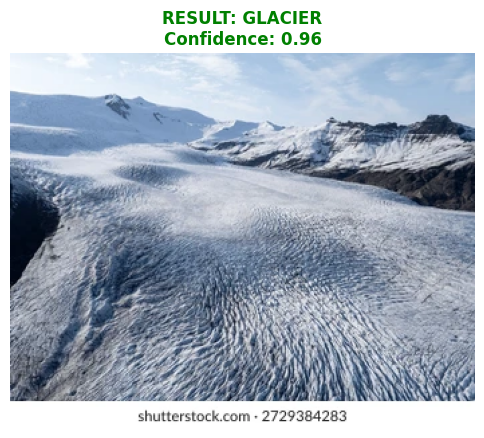

'Glacier'

In [16]:
predict_drone_vision('glacier.webp')

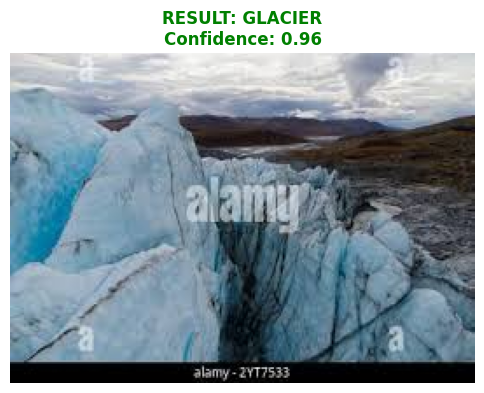

'Glacier'

In [17]:
predict_drone_vision('img3.jpg')

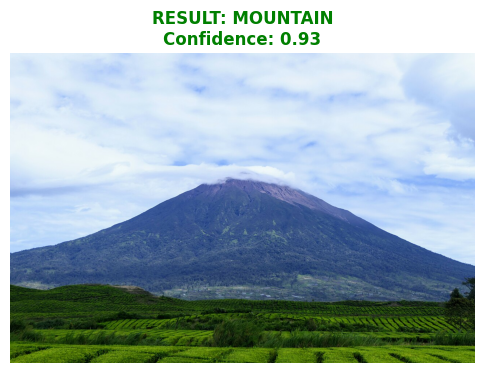

'Mountain'

In [18]:
predict_drone_vision('img4.jpg')

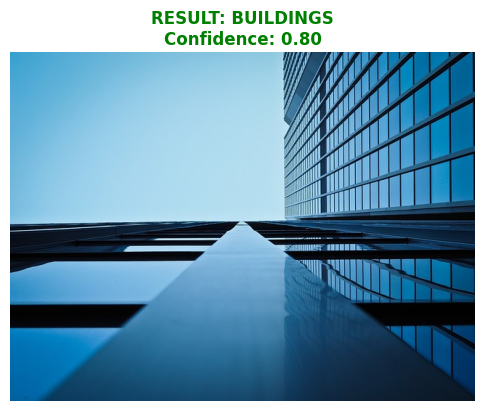

'Buildings'

In [19]:
predict_drone_vision('img8.jpg')

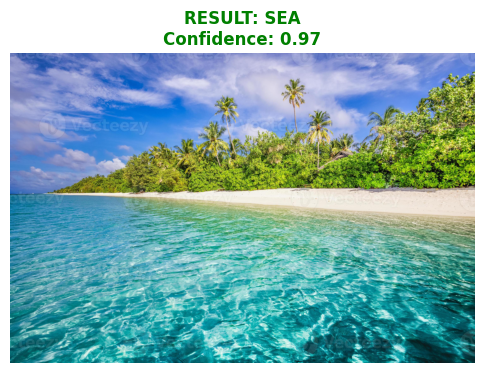

'Sea'

In [20]:
predict_drone_vision('img6.jpg')

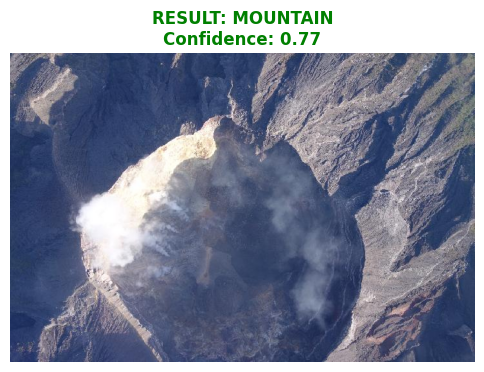

'Mountain'

In [21]:
predict_drone_vision('img1.jpg')

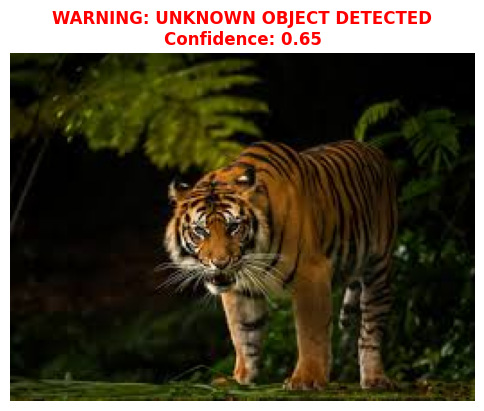

'Unknown'

In [24]:
predict_drone_vision('2.jpg')

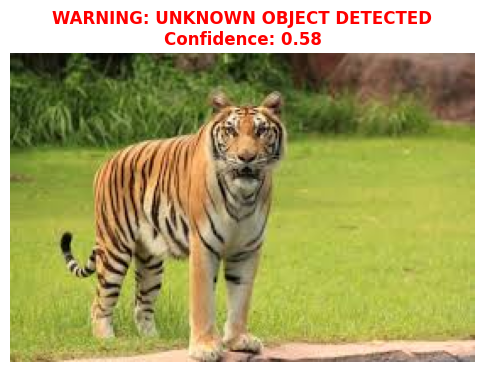

'Unknown'

In [27]:
predict_drone_vision('img5.jpg')